# Student Academic Risk Prediction Using Machine Learning

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve
)

In [3]:
df = pd.read_csv(r"student_risk_data_large.csv")
df

,study_hours,attendance,assignments,parent_education,previous_grade,final_score
0,7,57,8,high,63,97
1,4,63,5,high,68,78
2,5,72,10,high,88,91
3,7,89,4,medium,85,100
4,3,70,9,high,92,78
...,...,...,...,...,...,...
95,6,77,6,low,74,100
96,4,93,5,medium,94,88
97,6,93,8,high,79,97
98,7,69,10,low,91,100


In [4]:
df["at_risk"] = (df["final_score"] < 60).astype(int)
df

,study_hours,attendance,assignments,parent_education,previous_grade,final_score,at_risk
0,7,57,8,high,63,97,0
1,4,63,5,high,68,78,0
2,5,72,10,high,88,91,0
3,7,89,4,medium,85,100,0
4,3,70,9,high,92,78,0
...,...,...,...,...,...,...,...
95,6,77,6,low,74,100,0
96,4,93,5,medium,94,88,0
97,6,93,8,high,79,97,0
98,7,69,10,low,91,100,0


In [5]:

df["engagement_score"] = df["study_hours"] * df["attendance"]
df["performance_gap"] = df["previous_grade"] - df["assignments"]

In [6]:


X = df[[
    "study_hours", "attendance", "assignments",
    "previous_grade", "engagement_score",
    "performance_gap", "parent_education"
]]

y = df["at_risk"]

numeric_features = [
    "study_hours", "attendance", "assignments",
    "previous_grade", "engagement_score",
    "performance_gap"
]

categorical_features = ["parent_education"]


In [7]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [8]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


In [9]:
models = {
    "Logistic Regression": LogisticRegression(class_weight="balanced", max_iter=1000),
    "Random Forest": RandomForestClassifier(class_weight="balanced", random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

results = {}


In [10]:
for name, model in models.items():
    
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", model)
    ])
    
    pipeline.fit(X_train, y_train)
    
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]
    
    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    }

In [11]:
results_df = pd.DataFrame(results).T
print("\nModel Comparison:\n")
print(results_df)



Model Comparison:

                     Accuracy  Precision  Recall  F1 Score   ROC-AUC
Logistic Regression      0.90        0.8     0.8  0.800000  0.973333
Random Forest            0.90        1.0     0.6  0.750000  0.973333
Gradient Boosting        0.95        1.0     0.8  0.888889  0.986667


In [12]:
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        class_weight="balanced",
        random_state=42
    ))
])

param_grid = {
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [None, 5, 10],
    "classifier__min_samples_split": [2, 5],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    rf_pipeline,
    param_grid,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_

print("\nBest Parameters:", grid.best_params_)


Best Parameters: {'classifier__max_depth': None, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 100}


In [13]:

y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

print("\nFinal Model Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Final Model Performance:
Accuracy: 0.9
Precision: 0.8
Recall: 0.8
F1 Score: 0.8
ROC-AUC: 0.9733333333333334

Confusion Matrix:
 [[14  1]
 [ 1  4]]

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.93      0.93        15
           1       0.80      0.80      0.80         5

    accuracy                           0.90        20
   macro avg       0.87      0.87      0.87        20
weighted avg       0.90      0.90      0.90        20




Feature Importance:
                    Feature  Importance
4         engagement_score    0.333998
0              study_hours    0.308391
3           previous_grade    0.130811
5          performance_gap    0.102865
1               attendance    0.047151
2              assignments    0.032903
8  parent_education_medium    0.021718
7     parent_education_low    0.017660
6    parent_education_high    0.004501


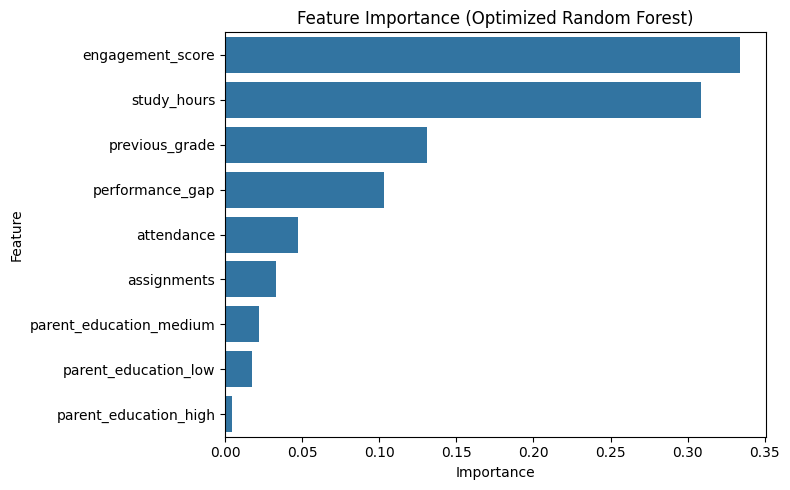

In [14]:

importances = best_model.named_steps["classifier"].feature_importances_

ohe = best_model.named_steps["preprocessor"].named_transformers_["cat"]
encoded_features = ohe.get_feature_names_out(categorical_features)

all_features = numeric_features + list(encoded_features)

importance_df = pd.DataFrame({
    "Feature": all_features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print("\nFeature Importance:\n", importance_df)

plt.figure(figsize=(8,5))
sns.barplot(x="Importance", y="Feature", data=importance_df)
plt.title("Feature Importance (Optimized Random Forest)")
plt.tight_layout()
plt.show()


In [15]:

joblib.dump(best_model, "student_risk_nit_level_model.pkl")
print("\nModel saved successfully.")


Model saved successfully.


# Early Detection of At-Risk Students Using Machine Learning and Predictive Analytics.